# Étape 5b - Duel : forêt aléatoire contre gradient boosting

## Objectif

L'étape 4 a laissé deux candidats : le gradient boosting devant la forêt aléatoire, 10,02
contre 10,28 de MAE en validation groupée, mais tous deux réglés par défaut. L'étape 5 a
optimisé la forêt sans la faire passer sous 10,1. Cette étape **choisit le modèle livré** :

1. **optimiser chacun séparément**, avec sa propre grille et le même protocole de
   sélection, pour que la comparaison soit équitable ;
2. **mesurer ce qui les sépare vraiment** : leurs prédictions divergent-elles, et où ;
3. **tester si les combiner vaut mieux** que choisir ;
4. **appliquer une règle de choix fixée avant le calcul** (section 3), et l'enregistrer.

**Règle du jeu de test.** Tout ce notebook travaille en validation croisée groupée sur les
seules formations d'apprentissage. Le jeu de test n'est pas construit : le modèle est
choisi avant qu'il soit ouvert, à l'étape 5c.

> **Révision du protocole** (voir [étape 10](../etapes/étape_10_revision.md)). La première
> version de ce duel, en plis aléatoires, avait déjà donné l'avantage au boosting, mais
> conservait la forêt parce qu'elle seule avait un score de test. Avec un découpage groupé
> et un test neuf, cet argument disparaît : le vainqueur du duel est le modèle livré.

In [1]:
import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (GridSearchCV, GroupKFold, GroupShuffleSplit,
                                     cross_val_predict, cross_validate)

PROJECT_PATH = Path.cwd().parent
sys.path.insert(0, str(PROJECT_PATH))
from modeles.protocole import (CODE_SISE, COLONNES_ENTREE, CV, FEATURES, TARGET,
                               creer_pipeline, decouper, identifiant_formation)

DATA_PATH = PROJECT_PATH / 'csv' / 'dataset_phase3_final.csv'
FIGURE_PATH = PROJECT_PATH / 'figures_eda'
CHOIX_PATH = PROJECT_PATH / 'modeles' / 'choix_modele.json'

COULEUR = '#2f6f9f'
COULEUR_ALT = '#d1793c'
COULEUR_NEUTRE = '#9aa5ad'
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
    'axes.grid': True, 'grid.alpha': 0.25,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'font.size': 9,
})

SOURCE_DONNEES = ('Source : InserSup, millésime 2026_S1 · promotions 2019 à 2024 · '
                  'MESR, Licence Ouverte Etalab')


def annoter_source(texte=SOURCE_DONNEES):
    """Appose la source et la période en pied de figure, juste avant l'export."""
    plt.gcf().text(0.995, -0.012, texte, ha='right', va='top',
                   fontsize=7, color=COULEUR_NEUTRE, style='italic')


df = pd.read_csv(DATA_PATH, dtype={CODE_SISE: str})

# Découpage groupé de l'étape 3, reproduit à l'identique ; le test n'est pas construit.
index_train, _ = decouper(df)
del _
X_train = df.loc[index_train, COLONNES_ENTREE]
y_train = df.loc[index_train, TARGET]
groupes_train = identifiant_formation(df.loc[index_train])

SCORING = {'rmse': 'neg_root_mean_squared_error', 'mae': 'neg_mean_absolute_error',
           'r2': 'r2'}

print(f'Apprentissage : {len(X_train)} lignes, {groupes_train.nunique()} formations, '
      f'{len(FEATURES)} variables')
print(f'Validation : {CV.get_n_splits()} plis groupés par formation, random_state=42')
print('Jeu de test : jamais construit dans ce notebook')

Apprentissage : 13718 lignes, 3958 formations, 18 variables
Validation : 5 plis groupés par formation, random_state=42
Jeu de test : jamais construit dans ce notebook


---

## 1. Combien d'arbres, combien d'itérations ?

Avant d'explorer les grilles, une question de dimensionnement : à partir de quand ajouter
des arbres à la forêt, ou des itérations au boosting, ne sert plus à rien. Elle se règle
une fois, et elle évite ensuite de gaspiller la grille sur un paramètre qui ne discrimine
plus.

Les deux familles n'ont pas le même comportement : ajouter des arbres à une forêt ne peut
pas la faire surapprendre, seulement la stabiliser, alors qu'ajouter des itérations à un
boosting finit par le faire coller au bruit.

In [2]:
# Trois plis groupés suffisent pour une courbe de tendance.
CV_RAPIDE = GroupKFold(n_splits=3, shuffle=True, random_state=42)

convergence = []
for n_arbres in [50, 100, 200, 400]:
    scores = cross_validate(
        creer_pipeline(RandomForestRegressor(n_estimators=n_arbres, min_samples_leaf=2,
                                             random_state=42, n_jobs=-1)),
        X_train, y_train, groups=groupes_train, cv=CV_RAPIDE,
        scoring=SCORING, return_train_score=True, n_jobs=1)
    convergence.append({'famille': 'Forêt', 'paramètre': f'{n_arbres} arbres',
                        'valeur': n_arbres,
                        'RMSE': round(-scores['test_rmse'].mean(), 3),
                        'écart train − validation': round(
                            scores['train_r2'].mean() - scores['test_r2'].mean(), 3)})

for n_iter in [100, 200, 400, 800]:
    scores = cross_validate(
        creer_pipeline(HistGradientBoostingRegressor(max_iter=n_iter, early_stopping=False,
                                                     random_state=42)),
        X_train, y_train, groups=groupes_train, cv=CV_RAPIDE,
        scoring=SCORING, return_train_score=True, n_jobs=1)
    convergence.append({'famille': 'Boosting', 'paramètre': f'{n_iter} itérations',
                        'valeur': n_iter,
                        'RMSE': round(-scores['test_rmse'].mean(), 3),
                        'écart train − validation': round(
                            scores['train_r2'].mean() - scores['test_r2'].mean(), 3)})

convergence = pd.DataFrame(convergence)
print(convergence.to_string(index=False))

 famille      paramètre  valeur   RMSE  écart train − validation
   Forêt      50 arbres      50 13.638                     0.438
   Forêt     100 arbres     100 13.598                     0.437
   Forêt     200 arbres     200 13.569                     0.436
   Forêt     400 arbres     400 13.546                     0.435
Boosting 100 itérations     100 13.132                     0.179
Boosting 200 itérations     200 13.153                     0.257
Boosting 400 itérations     400 13.335                     0.353
Boosting 800 itérations     800 13.589                     0.449


**Lecture.** Les deux courbes ne disent pas la même chose, et c'est tout l'intérêt de les
regarder séparément.

La forêt gagne l'essentiel entre 50 et 200 arbres, puis plafonne : passer de 200 à 400
change la RMSE de 0,02 point, pour le double de temps de calcul et un fichier de modèle
deux fois plus lourd. L'écart entraînement / validation ne bouge pratiquement pas,
ce qui confirme qu'ajouter des arbres ne fait pas surapprendre une forêt.

Le boosting, lui, voit son écart entraînement / validation **croître** avec les itérations,
de 0,18 à 0,45, et sa RMSE remonte dès 200 itérations :
chaque itération supplémentaire corrige les erreurs résiduelles, et à un moment elle corrige
du bruit. C'est pourquoi sa grille doit explorer le taux d'apprentissage et la taille des
arbres, pas seulement leur nombre.

La suite fixe donc le nombre d'arbres de la forêt à 300, valeur au-delà du plateau, et
laisse le boosting arbitrer lui-même entre nombre d'itérations et taux d'apprentissage.

---

## 2. Deux grilles, un même protocole de sélection

Chaque famille reçoit les paramètres qui comptent pour elle. Les comparer à grille identique
n'aurait aucun sens : ce ne sont pas les mêmes leviers.

| Forêt aléatoire | Pourquoi ce paramètre |
|---|---|
| `max_features` : `sqrt`, 0.3, 0.5, 0.8 | Le vrai levier d'une forêt : moins de variables par nœud, plus les arbres se décorrèlent |
| `min_samples_leaf` : 1, 2, 5, 10 | Contrôle direct de la profondeur effective, donc du surapprentissage |

| Gradient boosting | Pourquoi ce paramètre |
|---|---|
| `learning_rate` : 0.03, 0.06, 0.1 | Le levier central : un pas plus petit demande plus d'itérations mais généralise mieux |
| `max_leaf_nodes` : 15, 31, 63 | Complexité de chaque arbre, donc capacité à capter des interactions |
| `min_samples_leaf` : 10, 20 | Garde-fou sur les feuilles trop spécifiques |

**Même protocole de sélection pour les deux** : sélection sur la RMSE, puis règle à un
écart-type, exactement comme à l'étape 5. Parmi les configurations dont la RMSE est à moins
d'un écart-type de la meilleure, on garde la plus simple.

In [3]:
GRILLE_FORET = {
    'modele__max_features': ['sqrt', 0.3, 0.5, 0.8],
    'modele__min_samples_leaf': [1, 2, 5, 10],
}

depart = time.time()
recherche_foret = GridSearchCV(
    creer_pipeline(RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)),
    GRILLE_FORET, cv=CV, scoring=SCORING, refit='rmse', return_train_score=True,
    # n_jobs=1 : la forêt parallélise déjà par threads, imbriquer deux niveaux échoue.
    n_jobs=1)
recherche_foret.fit(X_train, y_train, groups=groupes_train)
duree_foret = time.time() - depart


def tableau_grille(recherche, colonnes):
    """Met la grille à plat : scores de validation, d'entraînement et écart entre les deux."""
    resultats = pd.DataFrame(recherche.cv_results_)
    tableau = pd.DataFrame({nom: resultats[f'param_modele__{nom}'] for nom in colonnes})
    tableau['RMSE validation'] = (-resultats['mean_test_rmse']).round(3)
    tableau['RMSE (écart-type)'] = resultats['std_test_rmse'].round(3)
    tableau['MAE validation'] = (-resultats['mean_test_mae']).round(3)
    tableau['R² validation'] = resultats['mean_test_r2'].round(3)
    tableau['écart train − validation'] = (
        resultats['mean_train_r2'] - resultats['mean_test_r2']).round(3)
    tableau['rang'] = resultats['rank_test_rmse']
    return tableau


def appliquer_regle_un_ecart_type(tableau, criteres_simplicite, ordres):
    """Retient la configuration la plus simple parmi celles équivalentes à la meilleure."""
    meilleure = tableau.loc[tableau['rang'].idxmin()]
    seuil = meilleure['RMSE validation'] + meilleure['RMSE (écart-type)']
    equivalentes = tableau[tableau['RMSE validation'] <= seuil]
    retenue = equivalentes.sort_values(criteres_simplicite, ascending=ordres).iloc[0]
    return meilleure, seuil, equivalentes, retenue


grille_foret = tableau_grille(recherche_foret, ['max_features', 'min_samples_leaf'])

# max_features mêle un mot-clé et des proportions : on trie sur la part de variables
# réellement tirée à chaque nœud, sans quoi la comparaison str/float échouerait.
NB_COLONNES_ENCODEES = 149
grille_foret['max_features'] = grille_foret['max_features'].astype(str)
grille_foret['part_variables'] = grille_foret['max_features'].map(
    lambda valeur: np.sqrt(NB_COLONNES_ENCODEES) / NB_COLONNES_ENCODEES
    if valeur == 'sqrt' else float(valeur)).round(3)

meilleure_f, seuil_f, equivalentes_f, retenue_f = appliquer_regle_un_ecart_type(
    grille_foret, ['min_samples_leaf', 'part_variables'], [False, True])

PARAMETRES_FORET = {
    'n_estimators': 300,
    'max_features': ('sqrt' if retenue_f['max_features'] == 'sqrt'
                     else float(retenue_f['max_features'])),
    'min_samples_leaf': int(retenue_f['min_samples_leaf'])}

print(f'{len(grille_foret)} configurations × {CV.get_n_splits()} plis '
      f'en {duree_foret / 60:.1f} min')
print(f"Meilleure RMSE : {meilleure_f['RMSE validation']:.3f} "
      f"(± {meilleure_f['RMSE (écart-type)']:.3f}), seuil à {seuil_f:.3f}")
print(f'{len(equivalentes_f)} configurations statistiquement équivalentes')
print(f'Retenue : {PARAMETRES_FORET}')
grille_foret.sort_values('rang').head(8).reset_index(drop=True)

16 configurations × 5 plis en 2.9 min
Meilleure RMSE : 13.175 (± 0.301), seuil à 13.476
15 configurations statistiquement équivalentes
Retenue : {'n_estimators': 300, 'max_features': 0.3, 'min_samples_leaf': 10}


,max_features,min_samples_leaf,RMSE validation,RMSE (écart-type),MAE validation,R² validation,écart train − validation,rang,part_variables
0,sqrt,2,13.175,0.301,10.153,0.494,0.289,1,0.082
1,sqrt,1,13.212,0.282,10.154,0.491,0.451,2,0.082
2,0.3,2,13.225,0.349,10.137,0.490,0.385,3,0.300
3,0.3,5,13.232,0.359,10.163,0.489,0.247,4,0.300
4,0.3,1,13.232,0.341,10.141,0.489,0.454,5,0.300
5,0.5,2,13.285,0.352,10.175,0.485,0.405,6,0.500
6,0.5,5,13.291,0.374,10.196,0.485,0.274,7,0.500
7,0.5,1,13.322,0.331,10.205,0.482,0.461,8,0.500


In [4]:
GRILLE_BOOSTING = {
    'modele__learning_rate': [0.03, 0.06, 0.1],
    'modele__max_leaf_nodes': [15, 31, 63],
    'modele__min_samples_leaf': [10, 20],
}

depart = time.time()
recherche_boosting = GridSearchCV(
    creer_pipeline(HistGradientBoostingRegressor(max_iter=400, early_stopping=False,
                                                 random_state=42)),
    GRILLE_BOOSTING, cv=CV, scoring=SCORING, refit='rmse', return_train_score=True,
    n_jobs=1)
recherche_boosting.fit(X_train, y_train, groups=groupes_train)
duree_boosting = time.time() - depart

grille_boosting = tableau_grille(
    recherche_boosting, ['learning_rate', 'max_leaf_nodes', 'min_samples_leaf'])
meilleure_b, seuil_b, equivalentes_b, retenue_b = appliquer_regle_un_ecart_type(
    grille_boosting, ['max_leaf_nodes', 'min_samples_leaf', 'learning_rate'],
    [True, False, True])

PARAMETRES_BOOSTING = {'max_iter': 400, 'early_stopping': False,
                       'learning_rate': float(retenue_b['learning_rate']),
                       'max_leaf_nodes': int(retenue_b['max_leaf_nodes']),
                       'min_samples_leaf': int(retenue_b['min_samples_leaf'])}

print(f'{len(grille_boosting)} configurations × {CV.get_n_splits()} plis '
      f'en {duree_boosting / 60:.1f} min')
print(f"Meilleure RMSE : {meilleure_b['RMSE validation']:.3f} "
      f"(± {meilleure_b['RMSE (écart-type)']:.3f}), seuil à {seuil_b:.3f}")
print(f'{len(equivalentes_b)} configurations statistiquement équivalentes')
print(f'Retenue : {PARAMETRES_BOOSTING}')
grille_boosting.sort_values('rang').head(8).reset_index(drop=True)

18 configurations × 5 plis en 2.9 min
Meilleure RMSE : 12.950 (± 0.338), seuil à 13.288
16 configurations statistiquement équivalentes
Retenue : {'max_iter': 400, 'early_stopping': False, 'learning_rate': 0.03, 'max_leaf_nodes': 15, 'min_samples_leaf': 20}


,learning_rate,max_leaf_nodes,min_samples_leaf,RMSE validation,RMSE (écart-type),MAE validation,R² validation,écart train − validation,rang
0,0.03,31,10,12.950,0.338,9.965,0.511,0.180,1
1,0.06,15,10,12.967,0.322,9.992,0.510,0.165,2
2,0.03,31,20,12.975,0.345,9.981,0.509,0.174,3
3,0.03,63,10,13.018,0.325,10.002,0.506,0.272,4
4,0.10,15,10,13.023,0.305,10.022,0.505,0.224,5
5,0.06,15,20,13.026,0.286,10.013,0.505,0.161,6
6,0.03,63,20,13.030,0.360,10.020,0.505,0.262,7
7,0.06,31,10,13.034,0.357,10.018,0.505,0.262,8


---

## 3. Le duel, à armes égales

Les deux modèles optimisés, évalués sur les mêmes plis, avec la même pipeline. On y ajoute
un troisième concurrent qui ne coûte presque rien : la **moyenne des deux prédictions**.
Combiner deux modèles qui se trompent différemment réduit l'erreur, à condition qu'ils se
trompent bien différemment. C'est la mesure qui suit qui le dira.

**Règle de choix, fixée avant de lire les résultats.** Le modèle livré est celui des deux
dont la MAE hors pli est la plus faible. La moyenne des deux n'est retenue que si elle bat
le meilleur des deux de plus d'un écart-type entre plis : sinon, doubler le temps
d'entraînement et la taille du livrable ne se justifie pas.

In [5]:
foret = RandomForestRegressor(random_state=42, n_jobs=-1, **PARAMETRES_FORET)
boosting = HistGradientBoostingRegressor(random_state=42, **PARAMETRES_BOOSTING)

# Prédictions hors pli, plis groupés : chaque ligne est prédite par un modèle qui n'a vu
# aucune promotion de sa formation.
oof_foret = cross_val_predict(creer_pipeline(foret), X_train, y_train,
                              groups=groupes_train, cv=CV, n_jobs=1)
oof_boosting = cross_val_predict(creer_pipeline(boosting), X_train, y_train,
                                 groups=groupes_train, cv=CV, n_jobs=1)
oof_ensemble = (oof_foret + oof_boosting) / 2

vraies = y_train.to_numpy()


def mesurer(predictions):
    return {'MAE': round(mean_absolute_error(vraies, predictions), 3),
            'RMSE': round(mean_squared_error(vraies, predictions) ** 0.5, 3),
            'R²': round(r2_score(vraies, predictions), 3),
            'à ±5 pts': f'{100 * (np.abs(vraies - predictions) <= 5).mean():.1f} %',
            'ratées de +15 pts': f'{100 * (np.abs(vraies - predictions) > 15).mean():.1f} %'}


duel = pd.DataFrame({
    'Forêt optimisée': mesurer(oof_foret),
    'Boosting optimisé': mesurer(oof_boosting),
    'Moyenne des deux': mesurer(oof_ensemble),
}).T

ecart_modeles = np.abs(oof_foret - oof_boosting)
print(f'Corrélation entre les deux jeux de prédictions : '
      f'{np.corrcoef(oof_foret, oof_boosting)[0, 1]:.4f}')
print(f'Écart absolu moyen entre les deux : {ecart_modeles.mean():.2f} point')
print(f'Écart maximal : {ecart_modeles.max():.1f} points')
print(f'Formations où ils divergent de plus de 10 points : '
      f'{int((ecart_modeles > 10).sum())} sur {len(ecart_modeles)} '
      f'({100 * (ecart_modeles > 10).mean():.1f} %)')
print()
duel

Corrélation entre les deux jeux de prédictions : 0.9655
Écart absolu moyen entre les deux : 2.50 point
Écart maximal : 23.3 points
Formations où ils divergent de plus de 10 points : 122 sur 13718 (0.9 %)



,MAE,RMSE,R²,à ±5 pts,ratées de +15 pts
Forêt optimisée,10.261,13.346,0.481,32.3 %,23.4 %
Boosting optimisé,10.084,13.097,0.5,32.6 %,22.8 %
Moyenne des deux,10.085,13.119,0.499,32.4 %,22.7 %


---

## 4. Où chacun gagne

Une moyenne globale peut cacher deux profils d'erreur opposés. On découpe donc l'erreur par
groupe, pour voir si l'un des deux modèles est meilleur là où l'autre échoue.

In [6]:
analyse = X_train.copy()
analyse['erreur_foret'] = np.abs(vraies - oof_foret)
analyse['erreur_boosting'] = np.abs(vraies - oof_boosting)

decoupages = {
    'Taille de formation': 'tranche_effectif',
    'Domaine disciplinaire': 'Domaine disciplinaire',
    'Promotion': 'Promotion',
}

comparaisons = []
for intitule, colonne in decoupages.items():
    par_groupe = analyse.groupby(colonne)[['erreur_foret', 'erreur_boosting']].mean()
    effectifs = analyse.groupby(colonne).size()
    for groupe in par_groupe.index:
        mae_f = par_groupe.loc[groupe, 'erreur_foret']
        mae_b = par_groupe.loc[groupe, 'erreur_boosting']
        comparaisons.append({
            'découpage': intitule, 'groupe': str(groupe),
            'formations': int(effectifs[groupe]),
            'MAE forêt': round(mae_f, 2), 'MAE boosting': round(mae_b, 2),
            'écart': round(mae_b - mae_f, 2),
            'gagnant': 'forêt' if mae_f < mae_b else 'boosting'})

comparaisons = pd.DataFrame(comparaisons)
victoires = comparaisons['gagnant'].value_counts()
print(f'Groupes remportés : {dict(victoires)}')
print(f"Écart médian entre les deux, tous groupes confondus : "
      f"{comparaisons['écart'].abs().median():.2f} point de MAE")
print()
comparaisons.set_index(['découpage', 'groupe'])

Groupes remportés : {'boosting': np.int64(13), 'forêt': np.int64(1)}
Écart médian entre les deux, tous groupes confondus : 0.17 point de MAE



formations  MAE forêt  \
découpage             groupe                                                 
Taille de formation   grande (> 90)                        1835       7.50   
                      moyenne (46-90)                      3475       9.44   
                      petite (26-45)                       5149      10.69   
                      très petite (≤ 25)                   3259      12.01   
Domaine disciplinaire Droit, économie, gestion             4458      11.18   
                      Lettres, langues et arts             1408       9.44   
                      Sciences humaines et sociales        2207       9.18   
                      Sciences, technologies, santé        5645      10.16   
Promotion             2019                                 2139      10.39   
                      2020                                 2178      11.06   
                      2021                                 2360       9.99   
                      2022                                 2394       9.86   
                      2023                                 2294      10.16   
                      2024                                 2353      10.19   

                                                     MAE boosting  écart  \
découpage             groupe                                               
Taille de formation   grande (> 90)                          7.47  -0.03   
                      moyenne (46-90)                        9.21  -0.23   
                      petite (26-45)                        10.55  -0.14   
                      très petite (≤ 25)                    11.75  -0.26   
Domaine disciplinaire Droit, économie, gestion              10.78  -0.39   
                      Lettres, langues et arts               9.47   0.03   
                      Sciences humaines et sociales          9.07  -0.12   
                      Sciences, technologies, santé         10.08  -0.08   
Promotion             2019                                  10.19  -0.20   
                      2020                                  10.75  -0.31   
                      2021                                   9.80  -0.19   
                      2022                                   9.67  -0.19   
                      2023                                  10.04  -0.13   
                      2024                                  10.12  -0.06   

                                                      gagnant  
découpage             groupe                                   
Taille de formation   grande (> 90)                  boosting  
                      moyenne (46-90)                boosting  
                      petite (26-45)                 boosting  
                      très petite (≤ 25)             boosting  
Domaine disciplinaire Droit, économie, gestion       boosting  
                      Lettres, langues et arts          forêt  
                      Sciences humaines et sociales  boosting  
                      Sciences, technologies, santé  boosting  
Promotion             2019                           boosting  
                      2020                           boosting  
                      2021                           boosting  
                      2022                           boosting  
                      2023                           boosting  
                      2024                           boosting

---

## 5. Regardent-ils les mêmes variables ?

Deux modèles peuvent atteindre le même score en s'appuyant sur des signaux différents. Si
c'est le cas ici, la moyenne des deux a des chances d'être meilleure que chacun. On mesure
l'importance par permutation sur une part du jeu d'apprentissage réservée pour l'occasion,
groupée par formation, jamais sur le jeu de test. La permutation porte sur les 18 variables
du modèle, agrégats compris : elle est appliquée après l'étape `agregats` de la pipeline.

In [7]:
# Découpage interne au jeu d'apprentissage, groupé par formation : on entraîne sur 80 %
# des formations et on mesure l'importance sur les 20 % restantes. Le test reste fermé.
interne = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=7)
positions_ajuste, positions_mesure = next(interne.split(X_train, groups=groupes_train))
X_ajuste, X_mesure = X_train.iloc[positions_ajuste], X_train.iloc[positions_mesure]
y_ajuste, y_mesure = y_train.iloc[positions_ajuste], y_train.iloc[positions_mesure]

importances = {}
for nom, modele in [('forêt', foret), ('boosting', boosting)]:
    pipeline = creer_pipeline(modele)
    pipeline.fit(X_ajuste, y_ajuste)
    # Les agrégats sont calculés par la pipeline ajustée, puis on permute les 18 variables
    # que voit réellement le modèle.
    X_mesure_modele = pipeline.named_steps['agregats'].transform(X_mesure)[FEATURES]
    resultat = permutation_importance(pipeline[1:], X_mesure_modele, y_mesure, n_repeats=3,
                                      random_state=42, n_jobs=1,
                                      scoring='neg_root_mean_squared_error')
    importances[nom] = pd.Series(resultat.importances_mean, index=FEATURES)

comparaison_importances = pd.DataFrame(importances).round(4)
comparaison_importances['écart'] = (
    comparaison_importances['boosting'] - comparaison_importances['forêt']).round(4)
comparaison_importances = comparaison_importances.sort_values('forêt', ascending=False)

rang_foret = comparaison_importances['forêt'].rank(ascending=False)
rang_boosting = comparaison_importances['boosting'].rank(ascending=False)
print(f'Corrélation des rangs d\'importance (Spearman) : '
      f'{rang_foret.corr(rang_boosting, method="spearman"):.3f}')
print()
comparaison_importances.head(12)

Corrélation des rangs d'importance (Spearman) : 0.897



,forêt,boosting,écart
est_diplome_professionnalisant,2.1931,3.9596,1.7665
Type de diplôme,0.9474,0.4882,-0.4592
ratio_poursuite,0.9211,1.2340,0.3129
Domaine disciplinaire,0.7008,0.7879,0.0871
anciennete_promotion,0.5505,0.8491,0.2986
nb_etablissements_par_diplome,0.4791,0.5054,0.0263
6-Nombre de poursuivants - 6 mois après le diplôme,0.4738,0.4123,-0.0615
taille_mediane_secteur,0.3006,0.1604,-0.1402
Secteur disciplinaire,0.2025,0.5109,0.3084
Promotion,0.1714,0.3824,0.2110


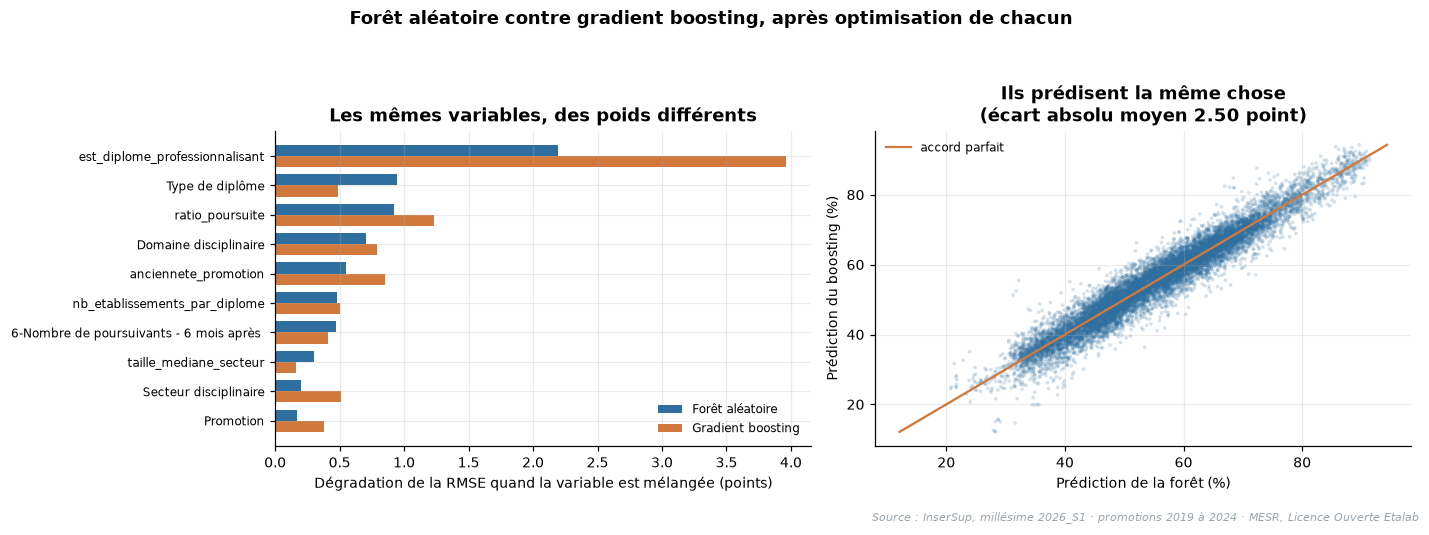

In [8]:
sommet = comparaison_importances.head(10).iloc[::-1]
positions = np.arange(len(sommet))
hauteur = 0.38

figure, axes = plt.subplots(1, 2, figsize=(13, 4.6))

axes[0].barh(positions + hauteur / 2, sommet['forêt'], hauteur,
             label='Forêt aléatoire', color=COULEUR)
axes[0].barh(positions - hauteur / 2, sommet['boosting'], hauteur,
             label='Gradient boosting', color=COULEUR_ALT)
axes[0].set_yticks(positions)
axes[0].set_yticklabels([nom[:40] for nom in sommet.index], fontsize=8)
axes[0].set_xlabel('Dégradation de la RMSE quand la variable est mélangée (points)')
axes[0].set_title('Les mêmes variables, des poids différents')
axes[0].legend(frameon=False, fontsize=8)

axes[1].scatter(oof_foret, oof_boosting, s=6, alpha=0.2, color=COULEUR, edgecolor='none')
limites = [min(oof_foret.min(), oof_boosting.min()), max(oof_foret.max(), oof_boosting.max())]
axes[1].plot(limites, limites, color=COULEUR_ALT, linewidth=1.5, label='accord parfait')
axes[1].set_xlabel('Prédiction de la forêt (%)')
axes[1].set_ylabel('Prédiction du boosting (%)')
axes[1].set_title(f'Ils prédisent la même chose\n(écart absolu moyen '
                  f'{ecart_modeles.mean():.2f} point)')
axes[1].legend(frameon=False, fontsize=8)

figure.suptitle('Forêt aléatoire contre gradient boosting, après optimisation de chacun',
                fontsize=12, fontweight='bold')
figure.tight_layout(rect=(0, 0, 1, 0.93))
annoter_source()
plt.savefig(FIGURE_PATH / 'fig18_duel_foret_boosting.png')
plt.show()

In [9]:
# Application de la règle fixée en section 3, puis enregistrement du choix pour l'étape 5c.
# Les MAE par pli se lisent sur les prédictions hors pli déjà calculées : mêmes plis groupés.
plis = [positions_validation for _, positions_validation
        in CV.split(X_train, y_train, groups=groupes_train)]
mae_par_pli = {
    nom: np.array([mean_absolute_error(vraies[p], oof[p]) for p in plis])
    for nom, oof in [('Forêt aléatoire', oof_foret), ('Gradient boosting', oof_boosting)]
}
mae_moyennes = {nom: mean_absolute_error(vraies, oof) for nom, oof
                in [('Forêt aléatoire', oof_foret), ('Gradient boosting', oof_boosting)]}
vainqueur = min(mae_moyennes, key=mae_moyennes.get)
autre = max(mae_moyennes, key=mae_moyennes.get)
ecart_type = mae_par_pli[vainqueur].std()
gain_ensemble = mae_moyennes[vainqueur] - mean_absolute_error(vraies, oof_ensemble)
assert gain_ensemble <= ecart_type, 'La moyenne des deux bat le vainqueur : règle à revoir'

PARAMETRES = {'Forêt aléatoire': PARAMETRES_FORET, 'Gradient boosting': PARAMETRES_BOOSTING}
CLASSES = {'Forêt aléatoire': 'RandomForestRegressor',
           'Gradient boosting': 'HistGradientBoostingRegressor'}
choix = {
    'modele': vainqueur,
    'classe': CLASSES[vainqueur],
    'parametres': PARAMETRES[vainqueur],
    'mae_validation_groupee': {nom: round(float(v), 3) for nom, v in mae_moyennes.items()},
    'ecart_type_entre_plis': round(float(ecart_type), 3),
    'regle': 'MAE hors pli la plus faible en validation croisée groupée',
}
CHOIX_PATH.write_text(json.dumps(choix, ensure_ascii=False, indent=2), encoding='utf-8')

for nom, valeurs in mae_par_pli.items():
    print(f'{nom:18} MAE {mae_moyennes[nom]:.3f} (± {valeurs.std():.3f}) · plis : '
          + ', '.join(f'{v:.2f}' for v in valeurs))
ecart = mae_moyennes[autre] - mae_moyennes[vainqueur]
print()
print(f'Écart : {ecart:.3f} point, soit {ecart / ecart_type:.1f} écart-type entre plis')
print(f'Plis gagnés par le vainqueur : '
      f'{int((mae_par_pli[vainqueur] < mae_par_pli[autre]).sum())} sur {len(plis)}')
print(f'Gain de la moyenne des deux sur le vainqueur : {gain_ensemble:+.3f} point')
print()
print(f'Modèle retenu : {vainqueur}, enregistré dans', CHOIX_PATH.relative_to(PROJECT_PATH))

Forêt aléatoire    MAE 10.261 (± 0.197) · plis : 10.35, 10.00, 10.13, 10.26, 10.57
Gradient boosting  MAE 10.084 (± 0.147) · plis : 10.18, 9.97, 9.94, 10.01, 10.33

Écart : 0.178 point, soit 1.2 écart-type entre plis
Plis gagnés par le vainqueur : 5 sur 5
Gain de la moyenne des deux sur le vainqueur : -0.001 point

Modèle retenu : Gradient boosting, enregistré dans modeles/choix_modele.json


---

## 6. Décision : le gradient boosting est retenu

| Modèle | MAE | RMSE | R² | à ±5 pts | ratées de +15 pts |
|---|---:|---:|---:|---:|---:|
| Forêt optimisée | 10,261 | 13,346 | 0,481 | 32,3 % | 23,4 % |
| **Boosting optimisé** | **10,084** | **13,097** | **0,500** | 32,6 % | 22,8 % |
| Moyenne des deux | 10,085 | 13,119 | 0,499 | 32,4 % | 22,7 % |

**La règle fixée en section 3 désigne le gradient boosting.** Sa MAE hors pli est plus
faible de 0,178 point, soit 1,2 écart-type entre plis. Pris isolément, cet écart serait
discutable ; sa régularité lui donne du poids : le boosting gagne **les cinq plis** et
**13 des 14 découpages** par taille, domaine et promotion. La forêt ne garde que Lettres,
langues et arts, pour 0,03 point.

**Les combiner n'apporte rien.** La moyenne des deux fait exactement le score du boosting
seul (10,085). C'est cohérent avec la ressemblance des deux modèles : prédictions corrélées
à 0,966, écart absolu moyen de 2,5 points, divergence de plus de 10 points sur 0,9 % des
formations seulement, et rangs d'importance corrélés à 0,897. Deux modèles qui se trompent
aux mêmes endroits ne se corrigent pas l'un l'autre.

**Ils exploitent le même signal, plus ou moins fort.** Le boosting s'appuie près de deux
fois plus sur `est_diplome_professionnalisant` (3,96 contre 2,19 points de RMSE) ; la forêt
pèse davantage sur le type de diplôme, qui porte en partie la même information.

**Le choix est enregistré** dans `modeles/choix_modele.json`, avant toute ouverture du
jeu de test. L'étape 5c entraîne ce modèle, le diagnostique en validation croisée, puis
ouvre le test une seule fois.

### Ce que l'optimisation a apporté, et ce qu'elle n'a pas apporté

Elle n'a pas fait baisser l'erreur. La forêt passe de 10,283 (étape 4) à 10,261, le boosting
de 10,017 avec ses réglages par défaut à 10,084 avec la configuration retenue. Ces écarts
sont tous inférieurs à l'écart-type entre plis : la règle à un écart-type a choisi, parmi
16 configurations équivalentes, la plus simple (pas d'apprentissage de 0,03, arbres de 15
feuilles, feuilles d'au moins 20 formations), pas la plus performante en apparence.

Ce que l'optimisation a apporté, c'est la **garantie que le classement tient** : le
boosting devançait la forêt réglée par défaut, il devance aussi la forêt optimisée, et sur
tous les plis. **Comparer deux modèles non optimisés ne dit rien de leur potentiel** ; ici,
l'optimisation confirme le classement au lieu de l'inverser.